# Carregando dados e imports

In [1]:
import json
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
from scipy.stats import wilcoxon, shapiro


with open('../data/raw/survey_responses.json', 'r', encoding="utf-8") as f:
    data = json.load(f)

print(f"Quantidade de respostas: {len(data)}")

Quantidade de respostas: 22


# Construção do DataFrame

In [2]:
rows = []
for user in data:
    row = {
        '_id': user['_id'],
        'gender': user['gender'],
        'category': user['category'],
        'yearsOfPractice': user['yearsOfPractice'],
        'birthDate': user['birthDate'],
        'locationState': user['locationState'],
        'locationCity': user['locationCity'],
        'workplaces': user['workplaces'],
        'specialties': user['specialties']
    }
    # preResearch: pre-usage, pre-knowledge, pre-tools
    for item in user.get('preResearch', []):
        row[item['questionId']] = int(item['answer']) if str(item['answer']).isdigit() else item['answer']
    # research questions
    for item in user.get('research', []):
        row[item['questionId']] = int(item['answer']) if str(item['answer']).isdigit() else item['answer']
    rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head()


(22, 22)


,_id,gender,category,yearsOfPractice,birthDate,locationState,locationCity,workplaces,specialties,pre-usage,...,user-aware-fig1,context-aware-fig1,objectivity-fig1,understandability-fig1,informative-fig1,user-aware-fig2,context-aware-fig2,objectivity-fig2,understandability-fig2,informative-fig2
0,{'$oid': '69bd7d0d2e936b062524caf8'},female,specialist,40,1962-01-17,SP,São Paulo,[teaching_hospital],"[Pediatria, Infectologia]",3,...,4,5,4,3,4,5,5,5,5,5
1,{'$oid': '69bd7ee32e936b062524cafa'},female,specialist,10,1982-04-20,SP,Marília,[private_clinic],[Dermatologia],2,...,4,4,4,4,4,4,4,4,4,4
2,{'$oid': '69bd81662e936b062524cafb'},female,specialist,26,1972-06-19,SP,São Paulo,"[public_hospital, private_clinic]",[Geriatria],2,...,4,3,4,4,4,5,3,5,5,4
3,{'$oid': '69bda2a42e936b062524cafc'},female,specialist,12,1982-11-20,SP,São Paulo,[teaching_hospital],[Ginecologia e Obstetrícia],3,...,4,4,4,3,4,4,4,4,4,4
4,{'$oid': '69c2fc212e936b062524cafd'},female,specialist,30,1972-02-25,SP,São Paulo,"[teaching_hospital, private_clinic]",[Psiquiatria],2,...,3,4,3,3,2,4,4,4,4,4


# Caracterização da amostra

Distribuição da amostra por estado, categoria, especialidade e local de trabalho.

In [3]:
df['locationState'].value_counts()

locationState
SP    16
MG     4
ES     1
CE     1
Name: count, dtype: int64

In [4]:
df['category'].value_counts()

category
specialist    21
resident       1
Name: count, dtype: int64

In [5]:
df['specialties'].value_counts()

specialties
[Psiquiatria]                            6
[Dermatologia]                           2
[Ginecologia e Obstetrícia]              2
[Radiologia e Diagnóstico por Imagem]    2
[Pediatria, Infectologia]                1
[Geriatria]                              1
[Reumatologia]                           1
[Coloproctologia]                        1
[Neurologia]                             1
[Endocrinologia e Metabologia]           1
[Anestesiologia]                         1
[Medicina do Trabalho]                   1
[Ortopedia e Traumatologia]              1
[Clínica Médica]                         1
Name: count, dtype: int64

In [6]:
df['workplaces'].value_counts()

workplaces
[private_clinic]                                                          4
[private_hospital]                                                        4
[public_hospital, private_clinic]                                         3
[teaching_hospital]                                                       2
[teaching_hospital, private_clinic]                                       2
[private_hospital, public_hospital, teaching_hospital, private_clinic]    2
[public_hospital]                                                         2
[public_hospital, teaching_hospital, private_clinic]                      1
[private_hospital, teaching_hospital, private_clinic]                     1
[private_hospital, public_hospital, private_clinic]                       1
Name: count, dtype: int64

## Atuação em hospital escola

Variável binária indicando se o médico atua (ou não) em hospital escola.

In [7]:
df['teaching_hospital'] = [
    1 if 'teaching_hospital' in user.get('workplaces', []) else 0
    for user in data
]

df['teaching_hospital'].value_counts()


teaching_hospital
0    14
1     8
Name: count, dtype: int64

# Estatísticas descritivas das respostas

In [8]:
pre_cols = ['pre-usage', 'pre-knowledge', 'pre-tools']
research_cols = [
    'user-aware-fig1', 'context-aware-fig1', 'objectivity-fig1',
    'understandability-fig1', 'informative-fig1',
    'user-aware-fig2', 'context-aware-fig2', 'objectivity-fig2',
    'understandability-fig2', 'informative-fig2',
]

cols = pre_cols + research_cols
stats = df[cols].agg(['min', 'max', 'mean', lambda x: x.mode()[0]]).T
stats.columns = ['mín', 'máx', 'média', 'moda']
stats['média'] = stats['média'].round(2)
stats.index.name = 'atributo'
stats


,mín,máx,média,moda
atributo,,,,
pre-usage,1.0,5.0,2.50,2.0
pre-knowledge,1.0,3.0,2.00,2.0
pre-tools,1.0,3.0,1.86,2.0
user-aware-fig1,1.0,5.0,3.64,4.0
context-aware-fig1,1.0,5.0,3.59,4.0
objectivity-fig1,1.0,5.0,3.45,4.0
understandability-fig1,1.0,5.0,3.36,3.0
informative-fig1,1.0,5.0,3.32,4.0
user-aware-fig2,2.0,5.0,3.95,4.0


# Matriz de correlação de Spearman

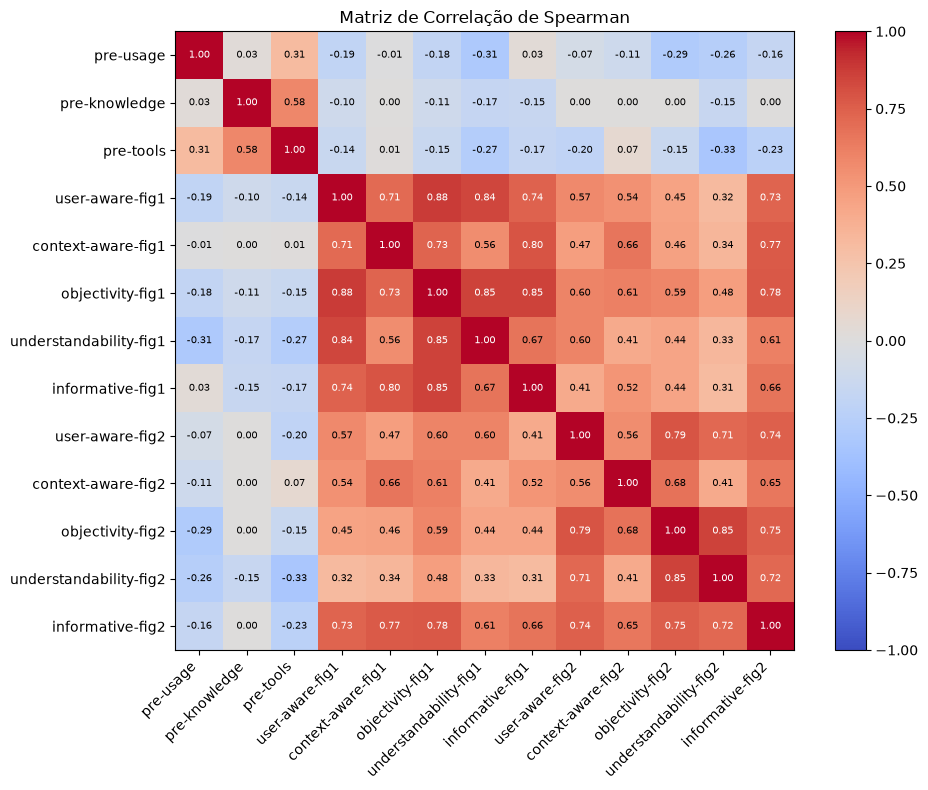

In [9]:
spearman_corr = df[cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(spearman_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{spearman_corr.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=7,
                color='black' if abs(spearman_corr.iloc[i, j]) < 0.7 else 'white')

ax.set_title('Matriz de Correlação de Spearman')
plt.tight_layout()
plt.show()


# Alfa de Cronbach das explicações

In [10]:
def cronbach_alpha(df_items):
    items = df_items.values
    k = items.shape[1]
    item_variances = items.var(axis=0, ddof=1)
    total_variance = items.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

fig1_cols = ['user-aware-fig1', 'context-aware-fig1', 'objectivity-fig1', 'understandability-fig1', 'informative-fig1']
fig2_cols = ['user-aware-fig2', 'context-aware-fig2', 'objectivity-fig2', 'understandability-fig2', 'informative-fig2']

alpha_fig1 = cronbach_alpha(df[fig1_cols])
alpha_fig2 = cronbach_alpha(df[fig2_cols])

print(f"Alpha de Cronbach - fig1: {alpha_fig1:.4f}")
print(f"Alpha de Cronbach - fig2: {alpha_fig2:.4f}")


Alpha de Cronbach - fig1: 0.9509
Alpha de Cronbach - fig2: 0.9192


O alfa de Cronbach calculado para as questões relacionadas às explicações globais foi de 0,951, enquanto o valor obtido para as questões referentes às explicações locais foi de 0,919, indicando elevada consistência interna em ambos os conjuntos de perguntas. Dessa forma, os itens de cada conjunto foram agregados por meio da média das respostas, gerando uma medida única para a avaliação das explicações globais e locais

# Médias agregadas: explicação global (fig. 1) vs local (fig. 2)

In [11]:
df['media_fig1'] = df[fig1_cols].mean(axis=1)
df['media_fig2'] = df[fig2_cols].mean(axis=1)

df[['media_fig1', 'media_fig2']].describe().round(2)


,media_fig1,media_fig2
count,22.00,22.00
mean,3.47,3.75
std,0.99,0.80
min,1.00,1.60
25%,3.00,3.25
50%,3.80,4.00
75%,4.00,4.15
max,5.00,5.00


## Densidade das médias (KDE)

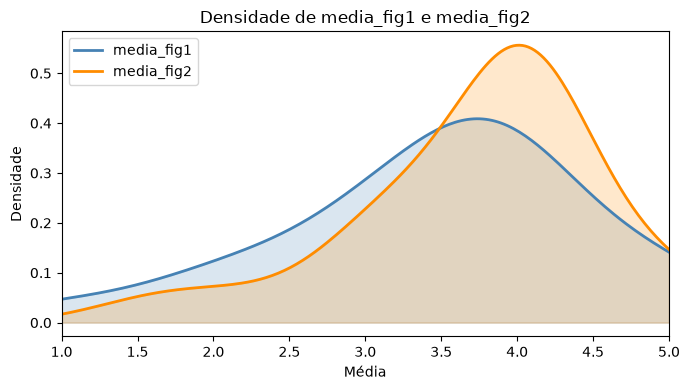

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

for col, color, label in [
    ('media_fig1', 'steelblue', 'media_fig1'),
    ('media_fig2', 'darkorange', 'media_fig2'),
]:
    values = df[col].dropna().values
    kde = gaussian_kde(values)
    x = np.linspace(1, 5, 200)
    y = kde(x)
    ax.plot(x, y, color=color, linewidth=2, label=label)
    ax.fill_between(x, y, alpha=0.2, color=color)

ax.set_title('Densidade de media_fig1 e media_fig2')
ax.set_xlabel('Média')
ax.set_ylabel('Densidade')
ax.set_xlim(1, 5)
ax.legend()
plt.tight_layout()
plt.show()


# Relações entre variáveis

## Pré-questionário vs médias das explicações

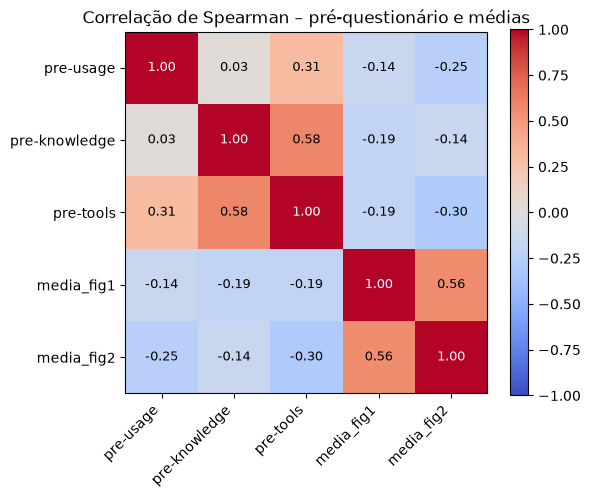

In [13]:
summary_cols = ['pre-usage', 'pre-knowledge', 'pre-tools', 'media_fig1', 'media_fig2']
spearman_summary = df[summary_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(spearman_summary, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(summary_cols)))
ax.set_yticks(range(len(summary_cols)))
ax.set_xticklabels(summary_cols, rotation=45, ha='right')
ax.set_yticklabels(summary_cols)

for i in range(len(summary_cols)):
    for j in range(len(summary_cols)):
        ax.text(j, i, f"{spearman_summary.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=9,
                color='black' if abs(spearman_summary.iloc[i, j]) < 0.7 else 'white')

ax.set_title('Correlação de Spearman – pré-questionário e médias')
plt.tight_layout()
plt.show()


## pre-tools vs media_fig2

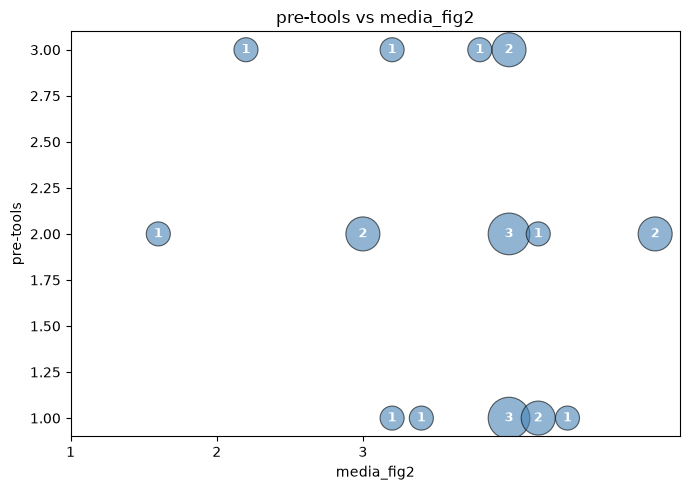

In [14]:
counts = df.groupby(['media_fig2', 'pre-tools']).size().reset_index(name='n')

fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(
    counts['media_fig2'],
    counts['pre-tools'],
    s=counts['n'] * 300,
    alpha=0.6,
    color='steelblue',
    edgecolors='black',
    linewidths=0.8
)

for _, row in counts.iterrows():
    ax.text(row['media_fig2'], row['pre-tools'], str(int(row['n'])),
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_ylabel('pre-tools')
ax.set_xlabel('media_fig2')
ax.set_title('pre-tools vs media_fig2')
ax.set_xticks(sorted(df['pre-tools'].unique()))
plt.tight_layout()
plt.show()


## Idade e anos de atuação vs médias

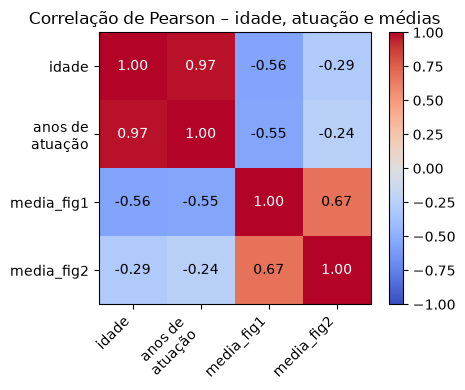

In [15]:
current_year = datetime.now().year
df['idade'] = df['birthDate'].apply(lambda d: current_year - datetime.strptime(d, '%Y-%m-%d').year)

demo_cols = ['idade', 'yearsOfPractice', 'media_fig1', 'media_fig2']
demo = df[demo_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(demo, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = ['idade', 'anos de\natuação', 'media_fig1', 'media_fig2']
ax.set_xticks(range(len(demo_cols)))
ax.set_yticks(range(len(demo_cols)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(demo_cols)):
    for j in range(len(demo_cols)):
        ax.text(j, i, f"{demo.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=10,
                color='black' if abs(demo.iloc[i, j]) < 0.7 else 'white')

ax.set_title('Correlação de Pearson – idade, atuação e médias')
plt.tight_layout()
plt.show()

## Anos de atuação vs media_fig1

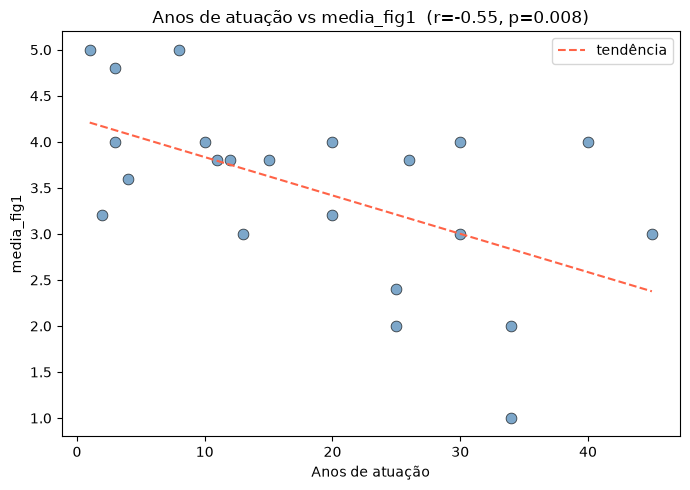

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['yearsOfPractice'], df['media_fig1'],
           color='steelblue', edgecolors='black', linewidths=0.6, alpha=0.7, s=60)

m, b = np.polyfit(df['yearsOfPractice'], df['media_fig1'], 1)
x_line = np.linspace(df['yearsOfPractice'].min(), df['yearsOfPractice'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, linestyle='--', label='tendência')

r, pval = pearsonr(df['yearsOfPractice'], df['media_fig1'])
ax.set_title(f'Anos de atuação vs media_fig1  (r={r:.2f}, p={pval:.3f})')
ax.set_xlabel('Anos de atuação')
ax.set_ylabel('media_fig1')
ax.legend()
plt.tight_layout()
plt.show()

O coeficiente de Pearson no título (r = -0.55, p = 0.008). A correlação negativa é estatisticamente significativa: médicos com mais anos de atuação tendem a dar notas menores para as explicações globais.

## Anos de atuação vs media_fig2

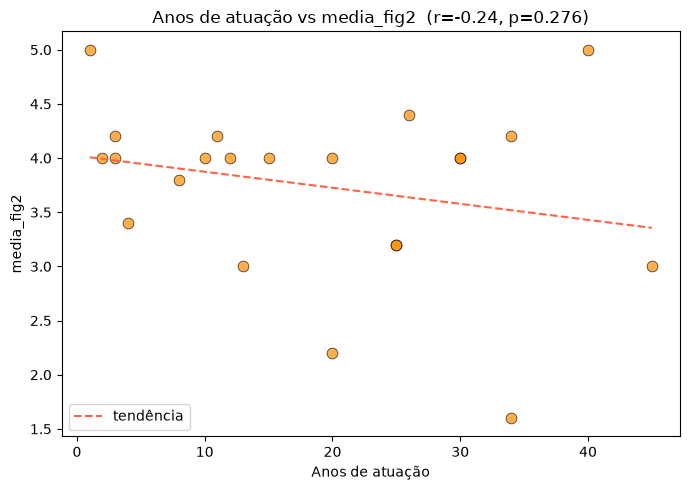

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['yearsOfPractice'], df['media_fig2'],
           color='darkorange', edgecolors='black', linewidths=0.6, alpha=0.7, s=60)

m, b = np.polyfit(df['yearsOfPractice'], df['media_fig2'], 1)
x_line = np.linspace(df['yearsOfPractice'].min(), df['yearsOfPractice'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, linestyle='--', label='tendência')

r, pval = pearsonr(df['yearsOfPractice'], df['media_fig2'])
ax.set_title(f'Anos de atuação vs media_fig2  (r={r:.2f}, p={pval:.3f})')
ax.set_xlabel('Anos de atuação')
ax.set_ylabel('media_fig2')
ax.legend()
plt.tight_layout()
plt.show()

Para media_fig2 a correlação é r = -0.24, p = 0.276 — fraca e não significativa, confirmando o padrão da matriz anterior: anos de atuação têm muito menos impacto na avaliação das explicações locais do que nas globais.

## Idade vs media_fig1

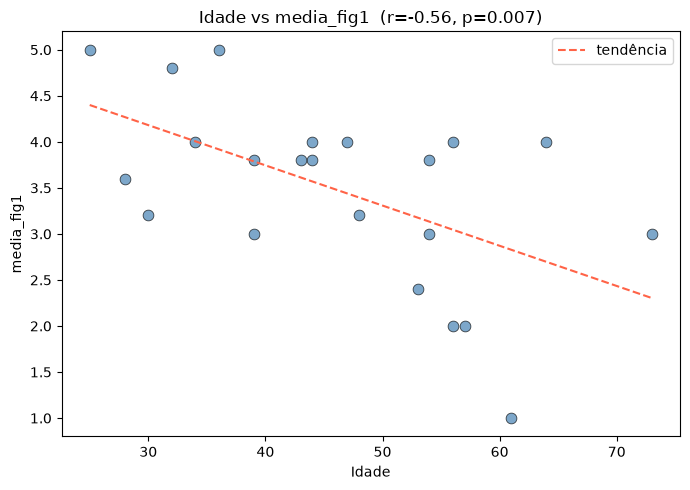

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['idade'], df['media_fig1'],
           color='steelblue', edgecolors='black', linewidths=0.6, alpha=0.7, s=60)

# linha de tendência
m, b = np.polyfit(df['idade'], df['media_fig1'], 1)
x_line = np.linspace(df['idade'].min(), df['idade'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, linestyle='--', label='tendência')

r, pval = pearsonr(df['idade'], df['media_fig1'])
ax.set_title(f'Idade vs media_fig1  (r={r:.2f}, p={pval:.3f})')
ax.set_xlabel('Idade')
ax.set_ylabel('media_fig1')
ax.legend()
plt.tight_layout()
plt.show()

O coeficiente de Pearson no título (r = -0.56, p = 0.007). A correlação negativa é estatisticamente significativa: médicos mais velhos tendem a dar notas menores para as explicações globais.

## Idade vs media_fig2

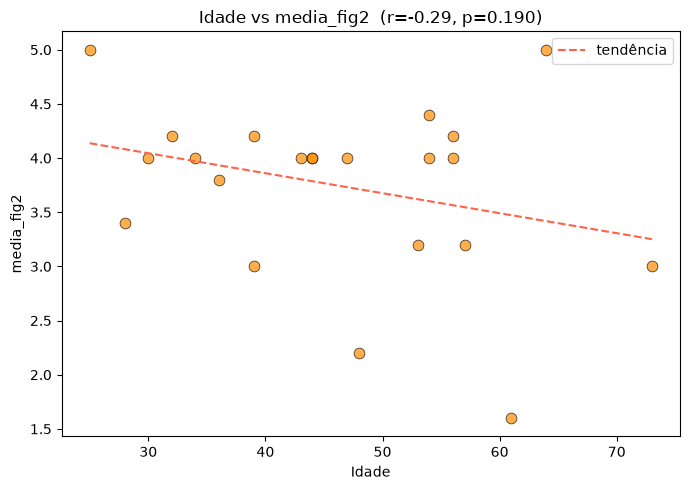

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['idade'], df['media_fig2'],
           color='darkorange', edgecolors='black', linewidths=0.6, alpha=0.7, s=60)

m, b = np.polyfit(df['idade'], df['media_fig2'], 1)
x_line = np.linspace(df['idade'].min(), df['idade'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5, linestyle='--', label='tendência')

r, pval = pearsonr(df['idade'], df['media_fig2'])
ax.set_title(f'Idade vs media_fig2  (r={r:.2f}, p={pval:.3f})')
ax.set_xlabel('Idade')
ax.set_ylabel('media_fig2')
ax.legend()
plt.tight_layout()
plt.show()

Para media_fig2 a correlação é r = -0.29, p = 0.190 — fraca e não significativa, confirmando o padrão da matriz anterior: a idade tem muito menos impacto na avaliação das explicações locais do que nas globais.

## media_fig2 por atuação em hospital escola

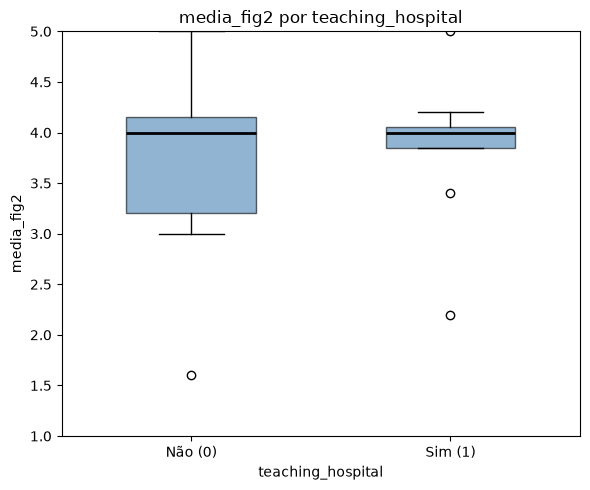

In [20]:
groups = [
    df.loc[df['teaching_hospital'] == 0, 'media_fig2'].values,
    df.loc[df['teaching_hospital'] == 1, 'media_fig2'].values,
]

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))

ax.set_xticks([1, 2])
ax.set_xticklabels(['Não (0)', 'Sim (1)'])
ax.set_xlabel('teaching_hospital')
ax.set_ylabel('media_fig2')
ax.set_title('media_fig2 por teaching_hospital')
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()


# Comparação global vs local: teste de Wilcoxon pareado

In [22]:
# Teste de normalidade das diferenças (Shapiro-Wilk)
diffs = df['media_fig2'] - df['media_fig1']
stat_sw, p_sw = shapiro(diffs)
print(f"Shapiro-Wilk nas diferenças: W={stat_sw:.4f}, p={p_sw:.4f}")

# Teste de Wilcoxon pareado (não paramétrico)
stat_w, p_w = wilcoxon(df['media_fig1'], df['media_fig2'])
print(f"\nTeste de Wilcoxon pareado:")
print(f"  Estatística = {stat_w:.4f}, p = {p_w:.4f}")
print(f"  {'Diferença significativa (p < 0.05)' if p_w < 0.05 else 'Sem diferença significativa (p >= 0.05)'}")

print(f"\nMédia media_fig1: {df['media_fig1'].mean():.3f}")
print(f"Média media_fig2: {df['media_fig2'].mean():.3f}")


Shapiro-Wilk nas diferenças: W=0.9493, p=0.3061

Teste de Wilcoxon pareado:
  Estatística = 31.5000, p = 0.1049
  Sem diferença significativa (p >= 0.05)

Média media_fig1: 3.473
Média media_fig2: 3.745


## Verificação da premissa de simetria (Wilcoxon)

O teste de Wilcoxon pareado assume que a distribuição das diferenças (media_fig2 - media_fig1) é aproximadamente simétrica em torno da mediana. Essa suposição recai sobre as diferenças, não sobre as notas brutas de media_fig1 e media_fig2, que podem ser assimétricas sem invalidar o teste.

In [23]:
# Coeficiente de assimetria (skewness) das notas brutas e das diferenças pareadas
skew_fig1 = df['media_fig1'].skew()
skew_fig2 = df['media_fig2'].skew()
skew_diffs = diffs.skew()

n_empates = (diffs == 0).sum()
pct_empates = n_empates / len(diffs)

print("Coeficiente de assimetria (skewness):")
print(f"  media_fig1 (bruta): {skew_fig1:.3f}")
print(f"  media_fig2 (bruta): {skew_fig2:.3f}")
print(f"  diferenças (media_fig2 - media_fig1): {skew_diffs:.3f}")

print(f"\nEmpates (diferença = 0): {n_empates} de {len(diffs)} pares ({pct_empates:.1%})")

Coeficiente de assimetria (skewness):
  media_fig1 (bruta): -0.684
  media_fig2 (bruta): -1.024
  diferenças (media_fig2 - media_fig1): 0.367

Empates (diferença = 0): 7 de 22 pares (31.8%)


As notas brutas de media_fig1 e media_fig2 são de fato assimétricas (skew ≈ -0.68 e -1.02, respectivamente), o que é esperado em escalas Likert limitadas e não compromete o teste. A premissa relevante do Wilcoxon é a simetria das **diferenças** pareadas, que apresentam assimetria bem mais leve (skew ≈ 0.37), sem indício forte de violação.

Ainda assim, vale registrar duas limitações que pedem cautela na interpretação: a amostra é pequena (n = 22) e cerca de 32% dos pares têm diferença exatamente zero, o que reduz a quantidade de pares informativos e o poder do teste. Diante disso, o resultado não significativo (p ≈ 0.105) deve ser lido como "não há evidência suficiente de diferença", e não como "não há diferença".